In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import sys
sys.path.append('../src')

from preprocessing import rename_columns, transform_variables, clean_data, process_status
from features import feature_engineering

# Pipeline completo de preparo
df_raw = pd.read_csv('../data/credit.csv')
df = (df_raw
      .pipe(rename_columns)
      .drop(df_raw.index[0])
      .pipe(transform_variables)
      .pipe(clean_data)
      .pipe(process_status)
      .pipe(feature_engineering))

X = df.drop(columns=['id', 'default'])
y = df['default']

# stratify=y garante a mesma proporção de default nos dois conjuntos
# Isso é crucial porque o dataset é desbalanceado (~22% default)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Default no treino: {y_train.mean():.2%} | no teste: {y_test.mean():.2%}")

Treino: (21000, 30) | Teste: (9000, 30)
Default no treino: 22.12% | no teste: 22.12%


In [ ]:
df.head()

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,pay_amt5,pay_amt6,default,avg_bill,util_ratio,pay_ratio_1,pay_ratio_2,pay_ratio_3,n_delays,max_delay
1,1,20000,2,2,1,24,2,2,0,0,...,0,0,1,1284.000000,0.064197,0.000000,0.998551,0.000000,2,2
2,2,120000,2,2,2,26,0,2,0,0,...,0,2000,1,2846.166667,0.023718,0.000000,0.372717,0.305530,2,2
3,3,90000,2,2,2,34,0,0,0,0,...,1000,5000,0,16942.166667,0.188244,0.108212,0.110619,0.069774,0,0
4,4,50000,2,2,1,37,0,0,0,0,...,1069,1000,0,38555.666667,0.771098,0.041465,0.040960,0.042380,0,0
5,5,50000,1,2,1,57,0,0,0,0,...,689,679,0,18223.166667,0.364456,0.352671,1.023580,0.477532,0,0


In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb   = XGBClassifier(
    n_estimators=300, #Quantidade de árvores contruídas
    learning_rate=0.05, #Peso de aprendizado dado a cada árvore
    max_depth=5, #Nível de profundidade das árvores
    subsample=0.8, #Usa apenas 80% das amostras escolhidas aleatoriamente
    colsample_bytree=0.8, #Usa apenas 80% das features disponíveis (Ambas funções servem para generalização)
    scale_pos_weight = neg/pos, #Declara um peso para a classe 1
    eval_metric='aucpr',  #Otimiza PR-AUC internamente
    random_state=42, #Garante a reprodutibilidade
    n_jobs=-1 
)

pipe = Pipeline ([
    #('smote', SMOTE(random_state=42)),
    ('xgb', xgb )
])

pipe.fit(X_train, y_train)

,steps,"[('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8


In [ ]:
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1] #Probabilidade da classe 1

array([0, 1, 0, ..., 0, 1, 0], shape=(9000,))

In [9]:
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Adimplente', 'Inadimplente']))

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
print(f"ROC-AUC : {roc_auc:.4f}  ← separação geral das classes")
print(f"PR-AUC  : {pr_auc:.4f}  ← mais relevante para dataset desbalanceado")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Adimplente       0.88      0.80      0.84      7009
Inadimplente       0.47      0.62      0.53      1991

    accuracy                           0.76      9000
   macro avg       0.67      0.71      0.69      9000
weighted avg       0.79      0.76      0.77      9000

ROC-AUC : 0.7754  ← separação geral das classes
PR-AUC  : 0.5536  ← mais relevante para dataset desbalanceado


In [10]:
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-9)
best_idx   = f1_scores.argmax()
best_thr   = thresholds[best_idx]

print(f"\nThreshold padrão (0.5) vs otimizado ({best_thr:.3f}):")
y_pred_default  = (y_proba >= 0.50).astype(int)
y_pred_tuned    = (y_proba >= best_thr).astype(int)

for label, pred in [("Threshold 0.50", y_pred_default), (f"Threshold {best_thr:.3f}", y_pred_tuned)]:
    report = classification_report(y_test, pred, target_names=['Adimplente', 'Inadimplente'],
                                   output_dict=True)
    recall_1    = report['Inadimplente']['recall']
    precision_1 = report['Inadimplente']['precision']
    f1_1        = report['Inadimplente']['f1-score']
    print(f"\n{label} → Recall: {recall_1:.3f} | Precision: {precision_1:.3f} | F1: {f1_1:.3f}")



Threshold padrão (0.5) vs otimizado (0.565):

Threshold 0.50 → Recall: 0.615 | Precision: 0.468 | F1: 0.532

Threshold 0.565 → Recall: 0.562 | Precision: 0.520 | F1: 0.540


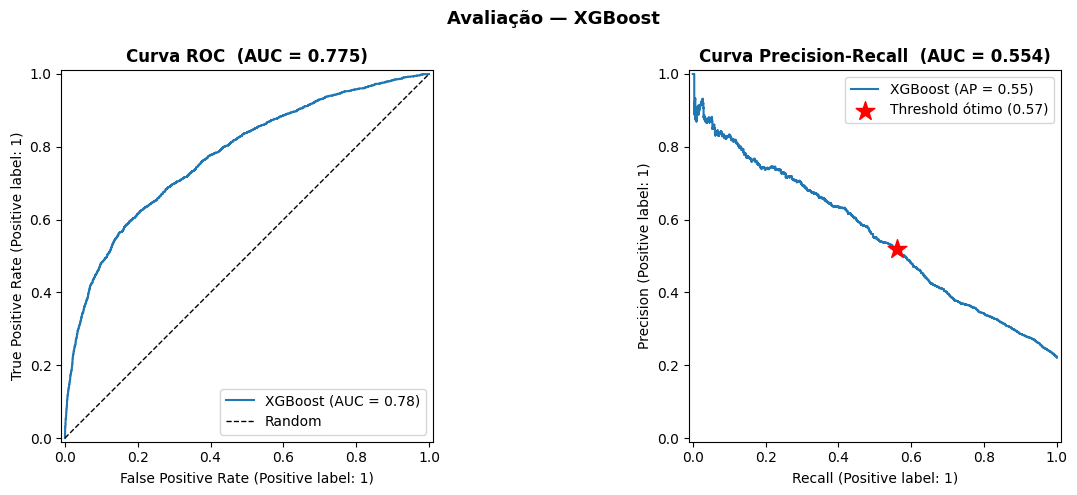

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='XGBoost')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_title(f'Curva ROC  (AUC = {roc_auc:.3f})', fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='XGBoost')
# Marca o threshold ótimo na curva PR
axes[1].scatter(recall_arr[best_idx], precision_arr[best_idx],
                marker='*', s=200, color='red', zorder=5,
                label=f'Threshold ótimo ({best_thr:.2f})')
axes[1].set_title(f'Curva Precision-Recall  (AUC = {pr_auc:.3f})', fontweight='bold')
axes[1].legend()

plt.suptitle('Avaliação — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/lr_evaluation.png', bbox_inches='tight')
plt.show()